# KTH-TIPS2 SPD Geometry Analysis

Notebook adaptation of `analysis.py`.

- **Task 1** — Manifold UMAP vs Tangent-Space UMAP  
- **Task 2** — Raw vs Standardized Tangent Features  
- **Task 3** — Downstream Classification with Nested CV (joblib parallel)

> Set `SUBSET` in the Configuration cell, then **Kernel → Restart & Run All**.

In [2]:
%matplotlib inline
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import trustworthiness
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from joblib import Parallel, delayed
import umap

from metric_functions import (
    compute_mean_projection,
    compute_pairwise_distance_matrix,
    project_stack_to_tangent_features,
    stack_npp_to_ppn,
)

warnings.filterwarnings("ignore", category=UserWarning, module="umap")

In [3]:
# ── Edit this block before running ───────────────────────────────────────────
SUBSET      = "debug"       # "debug" | "sample_a" | "sample_ab" | "full"
METRICS     = ["bw", "ai", "loge"]
LATENT_DIMS = [5, 10, 20]
N_OUTER     = 5
N_INNER     = 3
K_NEIGHBORS = 15
RANDOM_SEED = 42
N_JOBS      = -1
DATA_DIR    = os.path.join("data", "KTH-TIPS2-b")
FIG_DIR     = "figures"
RES_DIR     = "results"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

In [4]:
def load_data(subset: str):
    data  = np.load(os.path.join(DATA_DIR, "covariance_matrices.npz"), allow_pickle=True)
    X_all = data["X"]
    y_all = data["y"]
    meta  = pd.read_csv(os.path.join(DATA_DIR, "metadata.csv"))

    subset = subset.lower()
    if subset == "debug":
        mask = (meta["sample"] == "sample_a") & (meta["scale"].isin([2, 6, 10]))
    elif subset == "sample_a":
        mask = meta["sample"] == "sample_a"
    elif subset == "sample_ab":
        mask = meta["sample"].isin(["sample_a", "sample_b"])
    elif subset == "full":
        mask = pd.Series(np.ones(len(meta), dtype=bool))
    else:
        raise ValueError(f"Unknown SUBSET: {subset!r}")

    idx   = mask.values
    X     = X_all[idx]
    y_str = y_all[idx]
    meta_ = meta[idx].reset_index(drop=True)
    le    = LabelEncoder()
    y     = le.fit_transform(y_str)
    return X, y, y_str, meta_, le.classes_


def _class_colors(classes):
    cmap = plt.cm.get_cmap("tab20", len(classes))
    return {cls: cmap(i) for i, cls in enumerate(classes)}


def load_or_compute_D(X: np.ndarray, metric: str) -> np.ndarray:
    path = os.path.join(RES_DIR, f"pairwise_D_{metric}_{SUBSET}.npy")
    if os.path.exists(path):
        print(f"  Loading cached D: {path}")
        return np.load(path)
    print(f"  Computing pairwise {metric.upper()} distances...")
    t0 = time.time()
    D  = compute_pairwise_distance_matrix(X, metric=metric, verbose=True)
    np.save(path, D)
    print(f"  Done in {time.time() - t0:.1f}s — cached to {path}")
    return D

In [5]:
def run_one_combination(metric, pipeline_name, standardize, clf_name,
                        X, y, folds, latent_dims, n_inner, random_seed):
    """Full nested CV for one combination. Imports inside for joblib loky safety."""
    import numpy as _np
    import time as _time
    import umap as _umap
    from sklearn.decomposition import PCA as _PCA
    from sklearn.linear_model import LogisticRegression as _LR
    from sklearn.metrics import (accuracy_score, precision_score,
                                  recall_score, roc_auc_score)
    from sklearn.model_selection import GridSearchCV, StratifiedKFold
    from sklearn.neighbors import KNeighborsClassifier as _KNN
    from sklearn.pipeline import Pipeline as _Pipeline
    from sklearn.preprocessing import StandardScaler as _SS
    from sklearn.svm import SVC as _SVC
    from metric_functions import (compute_mean_projection, stack_npp_to_ppn,
                                   project_stack_to_tangent_features)

    if clf_name == "knn":
        clf      = _KNN()
        clf_grid = {"clf__n_neighbors": [3, 5, 11]}
    elif clf_name == "logreg":
        clf      = _LR(max_iter=1000, random_state=random_seed)
        clf_grid = {"clf__C": [0.01, 0.1, 1.0, 10.0]}
    else:
        clf      = _SVC(probability=True, random_state=random_seed)
        clf_grid = {"clf__C": [0.1, 1.0, 10.0], "clf__kernel": ["rbf", "linear"]}

    if pipeline_name == "A":
        pipe       = _Pipeline([("clf", clf)])
        param_grid = clf_grid
    elif pipeline_name == "B":
        pipe       = _Pipeline([("pca", _PCA()), ("clf", clf)])
        param_grid = {"pca__n_components": latent_dims, **clf_grid}
    else:
        pipe       = _Pipeline([
            ("umap", _umap.UMAP(random_state=random_seed, n_jobs=1)),
            ("clf", clf),
        ])
        param_grid = {"umap__n_components": latent_dims, **clf_grid}

    inner_cv    = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=random_seed)
    fold_scores = []
    t_start     = _time.time()

    for train_idx, test_idx in folds:
        X_tr_spd = X[train_idx]; X_te_spd = X[test_idx]
        y_tr     = y[train_idx]; y_te     = y[test_idx]

        M, _ = compute_mean_projection(stack_npp_to_ppn(X_tr_spd), metric=metric)
        Z_tr  = project_stack_to_tangent_features(X_tr_spd, M, metric=metric)
        Z_te  = project_stack_to_tangent_features(X_te_spd, M, metric=metric)

        if standardize:
            sc    = _SS()
            Z_tr  = sc.fit_transform(Z_tr)
            Z_te  = sc.transform(Z_te)

        gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                          scoring="accuracy", n_jobs=1, refit=True)
        gs.fit(Z_tr, y_tr)

        y_pred  = gs.predict(Z_te)
        y_proba = gs.predict_proba(Z_te)
        fold_scores.append({
            "accuracy":  accuracy_score(y_te, y_pred),
            "precision": precision_score(y_te, y_pred, average="macro", zero_division=0),
            "recall":    recall_score(y_te, y_pred, average="macro", zero_division=0),
            "auc":       roc_auc_score(y_te, y_proba, multi_class="ovr", average="macro"),
        })

    runtime = _time.time() - t_start
    sc_arr  = {k: _np.array([s[k] for s in fold_scores]) for k in fold_scores[0]}
    return {
        "metric":         metric.upper(),
        "pipeline":       pipeline_name,
        "standardized":   standardize,
        "classifier":     clf_name,
        "accuracy_mean":  round(float(sc_arr["accuracy"].mean()),  4),
        "accuracy_std":   round(float(sc_arr["accuracy"].std()),   4),
        "precision_mean": round(float(sc_arr["precision"].mean()), 4),
        "recall_mean":    round(float(sc_arr["recall"].mean()),    4),
        "auc_mean":       round(float(sc_arr["auc"].mean()),       4),
        "runtime_s":      round(runtime, 2),
    }

## Data Loading

In [7]:
X, y, y_str, meta, classes = load_data(SUBSET)
label_colors = _class_colors(classes)
print(f"Matrix shape: {X.shape}")

Matrix shape: (396, 22, 22)


C:\Users\cal3b\AppData\Local\Temp\ipykernel_41700\1769453158.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(classes))


---
## Task 1 — Manifold UMAP vs Tangent-Space UMAP

For each geometry (BW, AI, LogE):
1. Compute pairwise SPD distance matrix → manifold UMAP  
2. Compute barycenter → tangent features → tangent UMAP  
3. Compare with neighborhood overlap, trustworthiness, and Spearman ρ


[BW]
  Loading cached D: results\pairwise_D_bw_debug.npy
  Manifold UMAP...
  Barycenter + tangent features...
  Tangent UMAP...
  Computing comparison metrics...
  Overlap=0.8155  TW-manifold=0.9522  TW-tangent=0.9564  Spearman ρ=0.9408

[AI]
  Loading cached D: results\pairwise_D_ai_debug.npy
  Manifold UMAP...
  Barycenter + tangent features...
  Tangent UMAP...
  Computing comparison metrics...
  Overlap=0.5222  TW-manifold=0.9864  TW-tangent=0.9687  Spearman ρ=0.6212

[LOGE]
  Loading cached D: results\pairwise_D_loge_debug.npy
  Manifold UMAP...
  Barycenter + tangent features...
  Tangent UMAP...
  Computing comparison metrics...
  Overlap=0.9320  TW-manifold=0.9599  TW-tangent=0.9700  Spearman ρ=0.9953


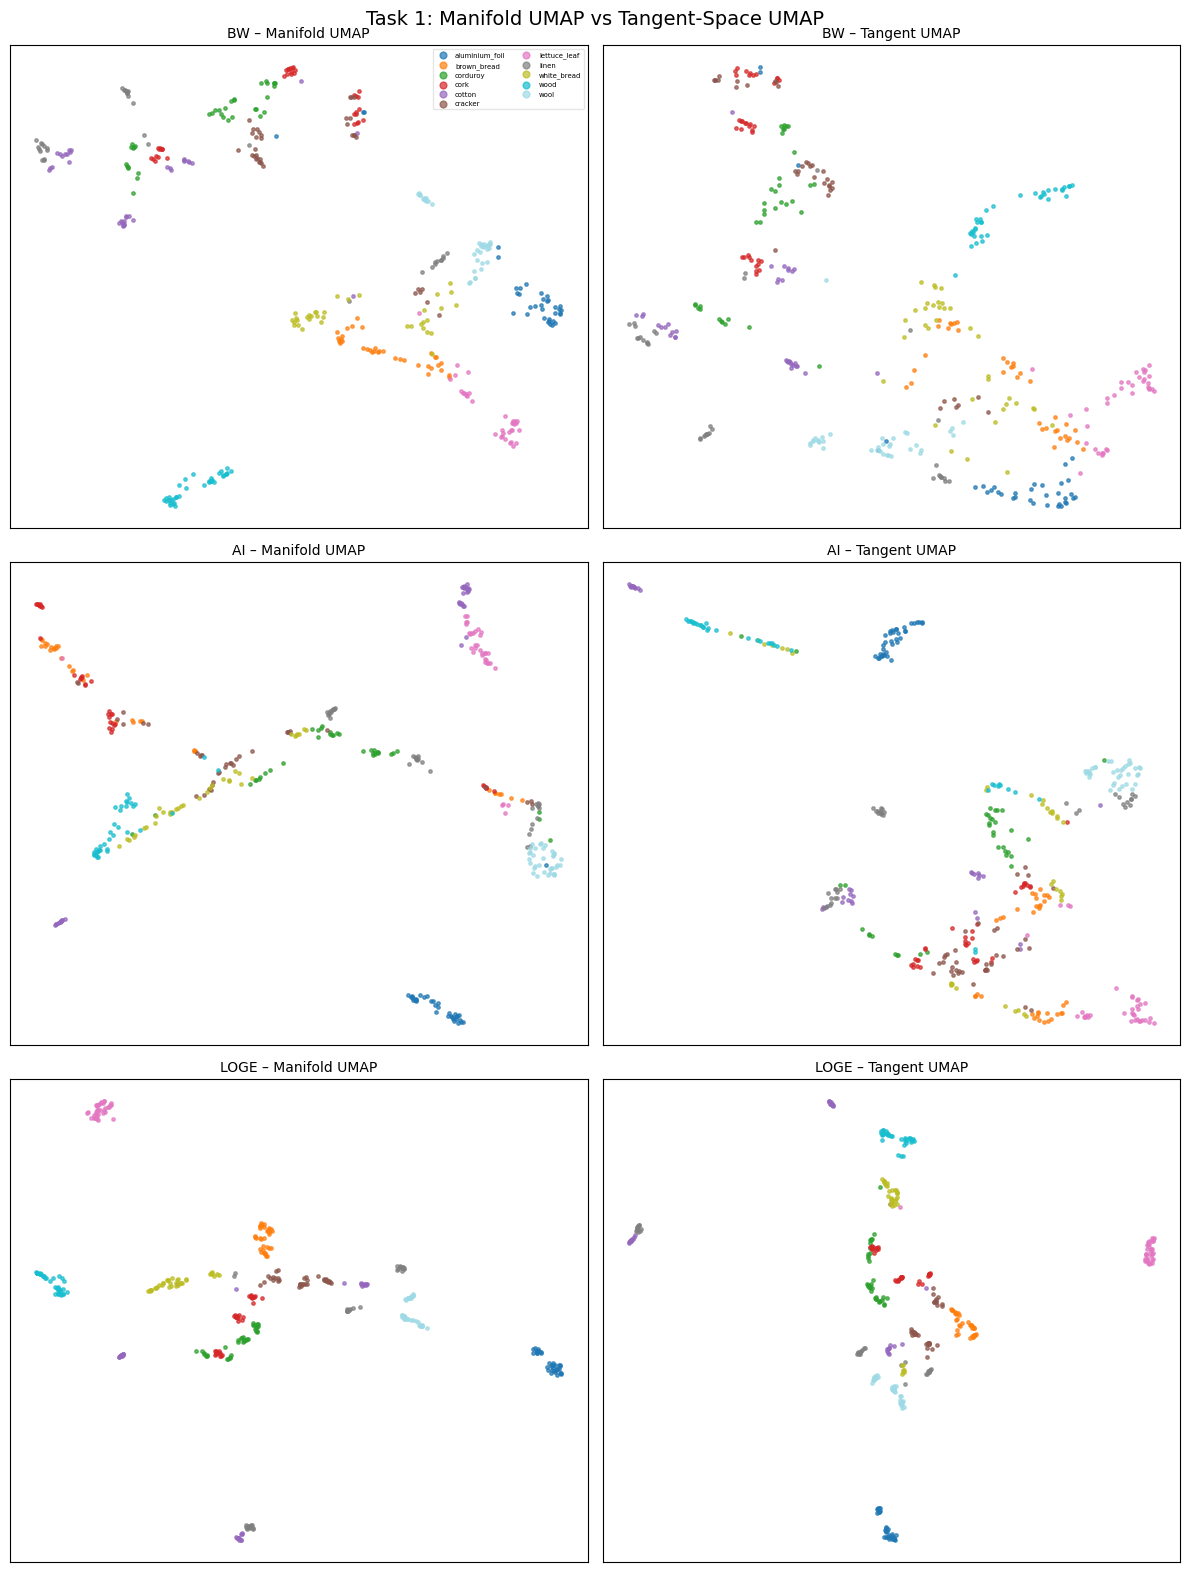

,metric,neighborhood_overlap,trustworthiness_manifold_umap,trustworthiness_tangent_umap,spearman_rho,spearman_pval
0,BW,0.8155,0.9522,0.9564,0.9408,0.0
1,AI,0.5222,0.9864,0.9687,0.6212,0.0
2,LOGE,0.9320,0.9599,0.9700,0.9953,0.0


In [9]:
task1_rows = []
fig, axes  = plt.subplots(3, 2, figsize=(12, 16))
fig.suptitle("Task 1: Manifold UMAP vs Tangent-Space UMAP", fontsize=14)

for row_idx, metric in enumerate(METRICS):
    print(f"\n[{metric.upper()}]")

    D = load_or_compute_D(X, metric)

    print("  Manifold UMAP...")
    emb_manifold = umap.UMAP(metric="precomputed", random_state=RANDOM_SEED,
                              n_jobs=1).fit_transform(D)

    print("  Barycenter + tangent features...")
    M, _ = compute_mean_projection(stack_npp_to_ppn(X), metric=metric)
    Z    = project_stack_to_tangent_features(X, M, metric=metric)

    print("  Tangent UMAP...")
    emb_tangent = umap.UMAP(metric="euclidean", random_state=RANDOM_SEED,
                             n_jobs=1).fit_transform(Z)

    for col_idx, (emb, title) in enumerate([
        (emb_manifold, f"{metric.upper()} – Manifold UMAP"),
        (emb_tangent,  f"{metric.upper()} – Tangent UMAP"),
    ]):
        ax = axes[row_idx, col_idx]
        for cls in classes:
            mask = y_str == cls
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       c=[label_colors[cls]], s=6, alpha=0.7, label=cls)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=5, markerscale=2, loc="best", ncol=2, framealpha=0.5)

    print("  Computing comparison metrics...")
    nbrs_m = (NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="precomputed")
              .fit(D).kneighbors(return_distance=False))
    nbrs_t = (NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="euclidean")
              .fit(Z).kneighbors(return_distance=False))
    overlap = float(np.mean([
        len(set(nbrs_m[i]) & set(nbrs_t[i])) / K_NEIGHBORS
        for i in range(len(D))
    ]))
    tw_m   = float(trustworthiness(D, emb_manifold, n_neighbors=K_NEIGHBORS,
                                   metric="precomputed"))
    tw_t   = float(trustworthiness(Z, emb_tangent,  n_neighbors=K_NEIGHBORS,
                                   metric="euclidean"))
    D_tan          = pairwise_distances(Z, metric="euclidean")
    upper          = np.triu_indices(len(D), k=1)
    rho, pval      = spearmanr(D[upper], D_tan[upper])

    print(f"  Overlap={overlap:.4f}  TW-manifold={tw_m:.4f}  "
          f"TW-tangent={tw_t:.4f}  Spearman ρ={float(rho):.4f}")
    task1_rows.append({
        "metric":                        metric.upper(),
        "neighborhood_overlap":          round(overlap,     4),
        "trustworthiness_manifold_umap": round(tw_m,        4),
        "trustworthiness_tangent_umap":  round(tw_t,        4),
        "spearman_rho":                  round(float(rho),  4),
        "spearman_pval":                 round(float(pval), 6),
    })

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task1_umap_grid.png"), dpi=150, bbox_inches="tight")
plt.show()

df_t1 = pd.DataFrame(task1_rows)
df_t1.to_csv(os.path.join(RES_DIR, "task1_metrics.csv"), index=False)
df_t1

---
## Task 2 — Raw vs Standardized Tangent Features

Three questions:
1. Do certain metrics naturally produce better-scaled tangent features? (boxplots)  
2. Does standardization change the latent structure? (PCA CVE — one plot per geometry)  
3. Does standardization affect classification performance? (barplot, KNN k=5)

In [11]:
# Compute raw tangent features for each geometry (full subset, no CV)
Z_raw        = {}
metric_color = {"bw": "#4C72B0", "ai": "#DD8452", "loge": "#55A868"}

for metric in METRICS:
    M, _ = compute_mean_projection(stack_npp_to_ppn(X), metric=metric)
    Z_raw[metric] = project_stack_to_tangent_features(X, M, metric=metric)
    print(f"{metric.upper()} tangent features: {Z_raw[metric].shape}")

BW tangent features: (396, 253)
AI tangent features: (396, 253)
LOGE tangent features: (396, 253)


C:\Users\cal3b\AppData\Local\Temp\ipykernel_41700\4014374741.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)


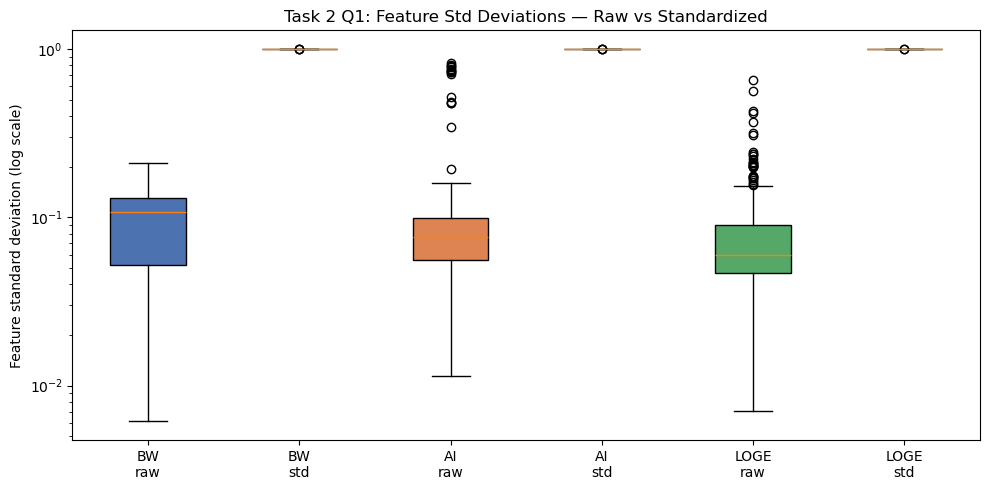

In [12]:
# ── Q1: Feature std boxplots ──────────────────────────────────────────────────
fig, ax         = plt.subplots(figsize=(10, 5))
box_data, box_labels, box_colors = [], [], []

for metric in METRICS:
    Z  = Z_raw[metric]
    Zs = StandardScaler().fit_transform(Z)
    box_data   += [Z.std(axis=0), Zs.std(axis=0)]
    box_labels += [f"{metric.upper()}\nraw", f"{metric.upper()}\nstd"]
    box_colors += [metric_color[metric], "lightgray"]

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)
for patch, col in zip(bp["boxes"], box_colors):
    patch.set_facecolor(col)
ax.set_yscale("log")
ax.set_ylabel("Feature standard deviation (log scale)")
ax.set_title("Task 2 Q1: Feature Std Deviations — Raw vs Standardized")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task2_feature_stds_boxplot.png"),
            dpi=150, bbox_inches="tight")
plt.show()

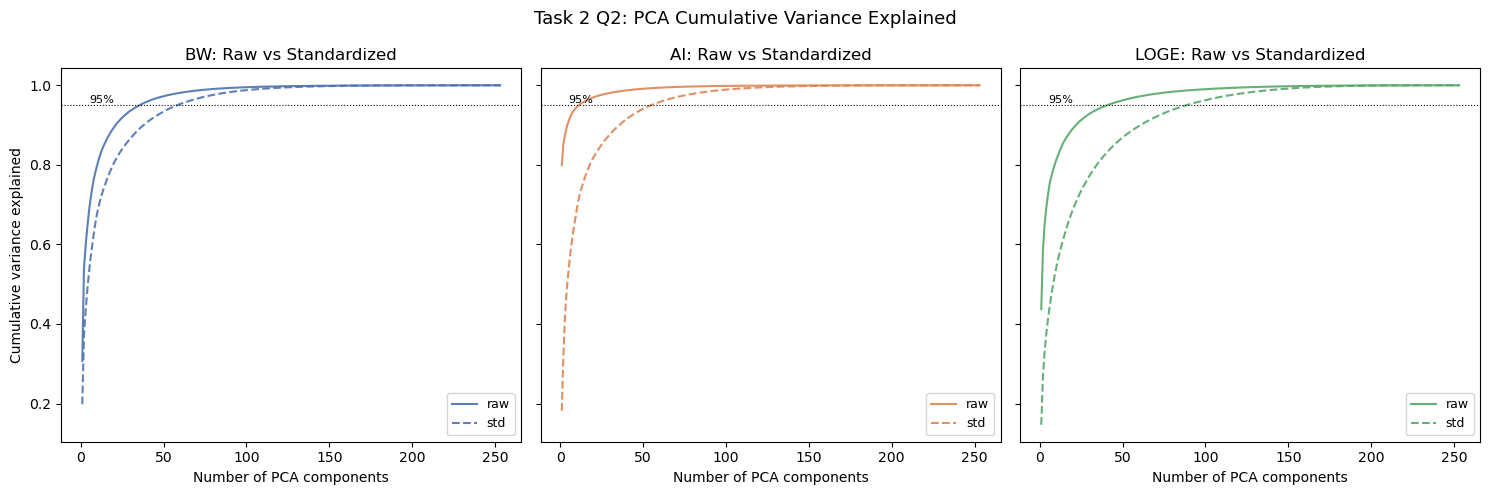

In [13]:
# ── Q2: PCA cumulative variance explained — one subplot per geometry ──────────
# Each panel shows raw (solid) vs standardized (dashed) for that geometry.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, metric in zip(axes, METRICS):
    Z  = Z_raw[metric]
    Zs = StandardScaler().fit_transform(Z)

    for Z_arr, label, ls, alpha in [
        (Z,  "raw", "-",  0.9),
        (Zs, "std", "--", 0.9),
    ]:
        cve = np.cumsum(PCA().fit(Z_arr).explained_variance_ratio_)
        ax.plot(range(1, len(cve) + 1), cve,
                linestyle=ls,
                color=metric_color[metric],
                alpha=alpha,
                label=label)

    ax.axhline(0.95, color="k", linewidth=0.8, linestyle=":")
    ax.text(5, 0.955, "95%", fontsize=8)
    ax.set_xlabel("Number of PCA components")
    ax.set_title(f"{metric.upper()}: Raw vs Standardized")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Cumulative variance explained")
fig.suptitle("Task 2 Q2: PCA Cumulative Variance Explained", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task2_pca_cve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Q3: Diagnostic classification accuracy (outer 5-fold, KNN k=5 only) ──────
diag_folds = list(StratifiedKFold(
    n_splits=N_OUTER, shuffle=True, random_state=RANDOM_SEED
).split(X, y))

diag_rows = []
for metric in METRICS:
    for std_flag in [False, True]:
        accs = []
        for tr_idx, te_idx in diag_folds:
            M, _ = compute_mean_projection(stack_npp_to_ppn(X[tr_idx]), metric=metric)
            Ztr  = project_stack_to_tangent_features(X[tr_idx], M, metric=metric)
            Zte  = project_stack_to_tangent_features(X[te_idx], M, metric=metric)
            if std_flag:
                sc  = StandardScaler()
                Ztr = sc.fit_transform(Ztr)
                Zte = sc.transform(Zte)
            clf = KNeighborsClassifier(n_neighbors=5)
            clf.fit(Ztr, y[tr_idx])
            accs.append(accuracy_score(y[te_idx], clf.predict(Zte)))
        diag_rows.append({
            "metric":        metric.upper(),
            "standardized":  std_flag,
            "accuracy_mean": round(float(np.mean(accs)), 4),
            "accuracy_std":  round(float(np.std(accs)),  4),
        })

df_diag = pd.DataFrame(diag_rows)
df_diag.to_csv(os.path.join(RES_DIR, "task2_standardization_accuracy.csv"), index=False)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(METRICS))
w = 0.35
for i, (flag, label, hatch) in enumerate([(False, "Raw", ""), (True, "Standardized", "//")]):
    sub = df_diag[df_diag["standardized"] == flag]
    ax.bar(x + i * w, sub["accuracy_mean"].values, w,
           yerr=sub["accuracy_std"].values, label=label, hatch=hatch, capsize=4)
ax.set_xticks(x + w / 2)
ax.set_xticklabels([m.upper() for m in METRICS])
ax.set_ylim(0, 1)
ax.set_ylabel("Mean accuracy (5-fold CV, KNN k=5)")
ax.set_title("Task 2 Q3: Classification Accuracy — Raw vs Standardized")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task2_classification_barplot.png"),
            dpi=150, bbox_inches="tight")
plt.show()
df_diag

---
## Task 3 — Downstream Classification with Nested CV

54 combinations: 3 geometries × 3 pipelines (A/B/C) × 2 standardization × 3 classifiers.  
Outer 5-fold CV + inner 3-fold GridSearchCV for hyperparameter tuning.  
All combinations dispatched in parallel via `joblib`.

**Fold indices are pre-generated once** so all combinations use identical splits.

In [ ]:
# Pre-generate fold indices ONCE — all 54 combinations use the same splits
folds = list(StratifiedKFold(
    n_splits=N_OUTER, shuffle=True, random_state=RANDOM_SEED
).split(X, y))

combos = [
    (metric, pipeline, std, clf)
    for metric   in METRICS
    for pipeline in ["A", "B", "C"]
    for std      in [False, True]
    for clf      in ["knn", "logreg", "svc"]
]
print(f"{len(combos)} combinations  "
      f"(outer {N_OUTER}-fold, inner {N_INNER}-fold, n_jobs={N_JOBS})")

t3 = time.time()
t3_results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(run_one_combination)(
        metric, pipeline, std, clf,
        X, y, folds, LATENT_DIMS, N_INNER, RANDOM_SEED,
    )
    for metric, pipeline, std, clf in combos
)
print(f"Total time: {time.time() - t3:.1f}s")

df_t3 = (pd.DataFrame(t3_results)
           .sort_values(["metric", "pipeline", "standardized", "classifier"])
           .reset_index(drop=True))
df_t3.to_csv(os.path.join(RES_DIR, "task3_classification_results.csv"), index=False)
df_t3

In [ ]:
# ── Summary heatmap: best accuracy per geometry × pipeline ───────────────────
best = (df_t3.groupby(["metric", "pipeline"])["accuracy_mean"]
              .max()
              .unstack("pipeline")[["A", "B", "C"]])

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(best.values, vmin=0, vmax=1, cmap="YlGn", aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["A  (full)", "B  (PCA)", "C  (UMAP)"])
ax.set_yticks(range(len(best.index)))
ax.set_yticklabels(best.index)
for i in range(len(best.index)):
    for j in range(3):
        ax.text(j, i, f"{best.values[i, j]:.3f}",
                ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Best accuracy (max over std / clf / q)")
ax.set_title("Task 3: Best Accuracy per Geometry × Pipeline")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "task3_accuracy_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()